# 🧠 The Problem of Overfitting

---

# 📓 Regularization: Addressing Overfitting in Linear and Logistic Regression

## 1. Executive Summary

This lecture introduces the fundamental challenge of overfitting in machine learning and presents regularization as a primary solution. Overfitting occurs when a model fits the training data too closely, capturing noise rather than the underlying pattern, which leads to poor performance on new, unseen data. The lecture contrasts overfitting with its counterpart, underfitting, where the model fails to capture even the basic patterns in the training data.

The core learning objectives include: understanding the bias-variance tradeoff (high bias = underfitting, high variance = overfitting), identifying when overfitting occurs in both regression and classification contexts, and implementing regularization techniques to prevent overfitting. The lecture provides three main strategies for addressing overfitting: collecting more training data, selecting fewer features, and applying regularization—with the last being the primary focus. By the end, you'll understand how to modify cost functions for both linear and logistic regression to include regularization terms, and how to implement regularized gradient descent.

## 2. Key Concepts & Glossary

| **Term** | **Definition** |
|----------|----------------|
| **Overfitting** | A modeling error where the function fits the training data too closely, capturing noise instead of the underlying pattern; results in poor generalization to new data |
| **Underfitting** | A modeling error where the function fails to capture the underlying trend of the data; model is too simple to represent the patterns |
| **High Bias** | Technical term for underfitting; the model has strong preconceptions that prevent it from fitting the training data well |
| **High Variance** | Technical term for overfitting; small changes in training data lead to large changes in model predictions |
| **Generalization** | The ability of a model to make correct predictions on new, unseen examples not used during training |
| **Regularization** | A technique that reduces overfitting by penalizing large parameter values, keeping all features but reducing their impact |
| **Regularization Parameter (λ)** | A value that controls the tradeoff between fitting the training data and keeping parameters small |
| **Feature Selection** | The process of choosing a subset of relevant features to use in model construction |
| **Cost Function** | A mathematical function that measures the error between predicted and actual values |
| **Gradient Descent** | An optimization algorithm used to minimize the cost function by iteratively updating parameters |

## 3. Important Data Points

### Key Formulas Summary

| **Formula Type** | **Expression** | **Purpose** |
|------------------|----------------|-------------|
| Linear Regression Cost | $J(\vec{w},b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})^2$ | Measures error for linear models |
| Regularized Linear Regression Cost | $J(\vec{w},b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2$ | Adds penalty for large parameters |
| Regularized Logistic Regression Cost | $J(\vec{w},b) = -\frac{1}{m}\sum_{i=1}^{m}[y^{(i)}\log(f_{\vec{w},b}(\vec{x}^{(i)})) + (1-y^{(i)})\log(1-f_{\vec{w},b}(\vec{x}^{(i)}))] + \frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2$ | Cross-entropy loss with regularization |



## 4. Core Concepts

### 4.1 The Problem of Overfitting

Overfitting occurs when a machine learning model learns the training data too well, including its noise and outliers. This results in a complex model that performs excellently on training data but poorly on new, unseen data. The opposite problem, underfitting, occurs when the model is too simple to capture the underlying patterns in the data.

**Real-world analogy**: Imagine studying for an exam by memorizing exact answers to practice questions without understanding the underlying concepts. You'll ace the practice test (training data) but fail when faced with new questions (test data) that require conceptual understanding.

### 4.2 Bias-Variance Tradeoff

The bias-variance tradeoff is a fundamental concept in machine learning:

- **High Bias (Underfitting)**: The model makes strong assumptions about the data (e.g., assuming linearity when the relationship is quadratic). It systematically misses the correct patterns.
- **High Variance (Overfitting)**: The model is highly sensitive to the specific training data. Small changes in the training set lead to dramatically different models.

The goal is to find the "just right" model that balances bias and variance, achieving good performance on both training and test data.

### 4.3 Regularization: A Gentle Approach to Feature Control

Regularization provides a middle ground between using all features and eliminating features entirely. Instead of setting parameters to zero (which removes features), regularization encourages the learning algorithm to shrink parameter values without demanding they become exactly zero.

**Key insight**: Regularization works by adding a penalty term to the cost function that grows with the size of the parameters. This creates a tradeoff between:
- Fitting the training data well (minimizing the original cost)
- Keeping parameters small (minimizing the regularization term)

The regularization parameter λ controls this tradeoff:
- λ = 0: No regularization (potentially overfitting)
- λ = very large: Parameters become nearly zero (underfitting)
- λ = "just right": Balanced model

### 4.4 Regularized Gradient Descent

For both linear and logistic regression, regularized gradient descent follows a similar pattern:

**For parameters wⱼ (j = 1 to n):**
$$w_j := w_j - \alpha\left[\frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})x_j^{(i)} + \frac{\lambda}{m}w_j\right]$$

**For parameter b (unregularized):**
$$b := b - \alpha\frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})$$

The key difference is the additional $\frac{\lambda}{m}w_j$ term that shrinks wⱼ on every iteration.

## 5. Visualizations

Let's recreate the key visualizations from the lecture to build intuition about overfitting, underfitting, and regularization.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

### 5.1 Underfitting, Just Right, and Overfitting in Regression


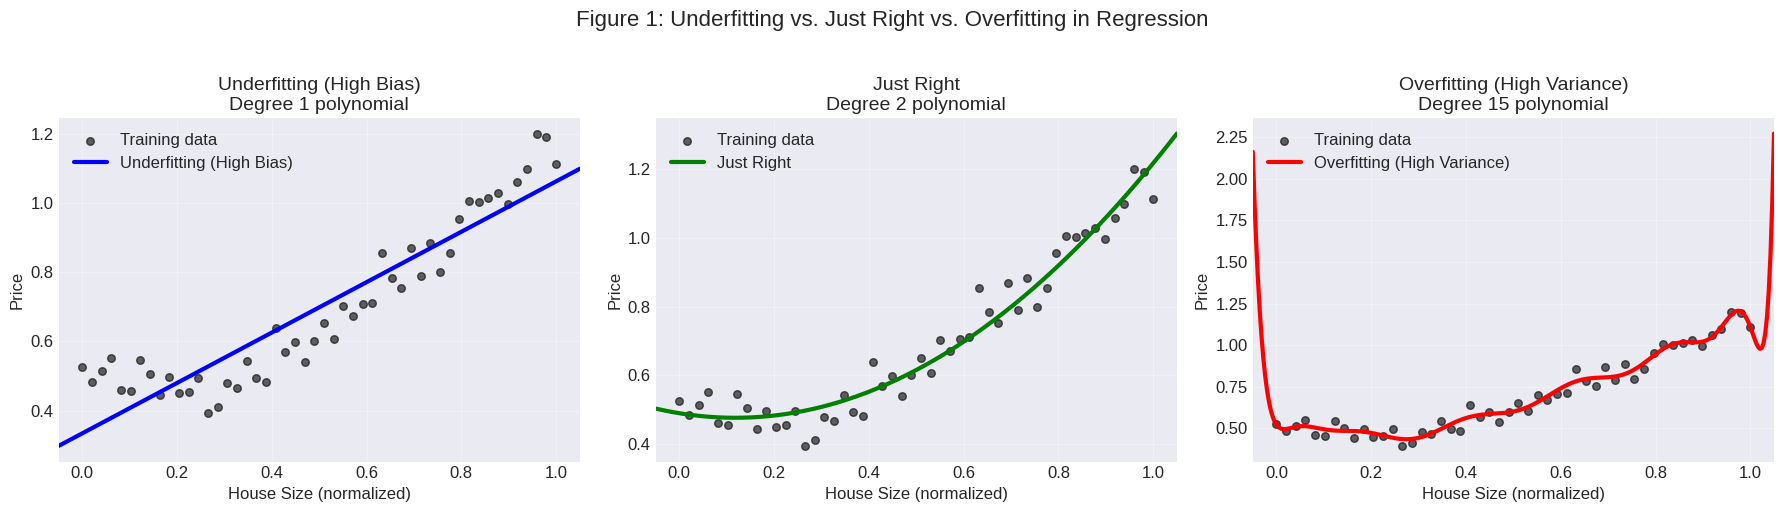

In [2]:
# Generate synthetic housing price data
np.random.seed(42)
m = 50
X = np.linspace(0, 1, m).reshape(-1, 1)
# True relationship: quadratic with plateau
y_true = 0.5 - 0.5 * X.ravel() + 2 * X.ravel()**2 - X.ravel()**3 + 0.2 * X.ravel()**4
# Add noise
y = y_true + 0.05 * np.random.randn(m)

# Create three models of increasing complexity
degrees = [1, 2, 15]  # Underfit, Just Right, Overfit
colors = ['blue', 'green', 'red']
labels = ['Underfitting (High Bias)', 'Just Right', 'Overfitting (High Variance)']

# Create the plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (degree, color, label) in enumerate(zip(degrees, colors, labels)):
    # Fit polynomial regression
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)

    # Predict for smooth curve
    X_test = np.linspace(-0.05, 1.05, 300).reshape(-1, 1)
    y_pred = model.predict(X_test)

    # Plot
    axes[idx].scatter(X, y, alpha=0.6, label='Training data', color='black', s=30)
    axes[idx].plot(X_test, y_pred, color=color, linewidth=3, label=label)
    axes[idx].set_xlabel('House Size (normalized)', fontsize=12)
    axes[idx].set_ylabel('Price', fontsize=12)
    axes[idx].set_title(f'{label}\nDegree {degree} polynomial', fontsize=14)
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([-0.05, 1.05])

plt.suptitle('Figure 1: Underfitting vs. Just Right vs. Overfitting in Regression', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Explanation**: This visualization demonstrates the three regimes of model fitting. The underfit model (degree 1 polynomial) is too simple and misses the curved pattern in the data. The "just right" model (degree 2 polynomial) captures the general trend without fitting the noise. The overfit model (degree 15 polynomial) passes through almost every training point but creates a wildly fluctuating curve that would perform poorly on new data.

### 5.2 Classification Example: Decision Boundaries

/tmp/ipykernel_575/88620574.py:88: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_575/88620574.py:88: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


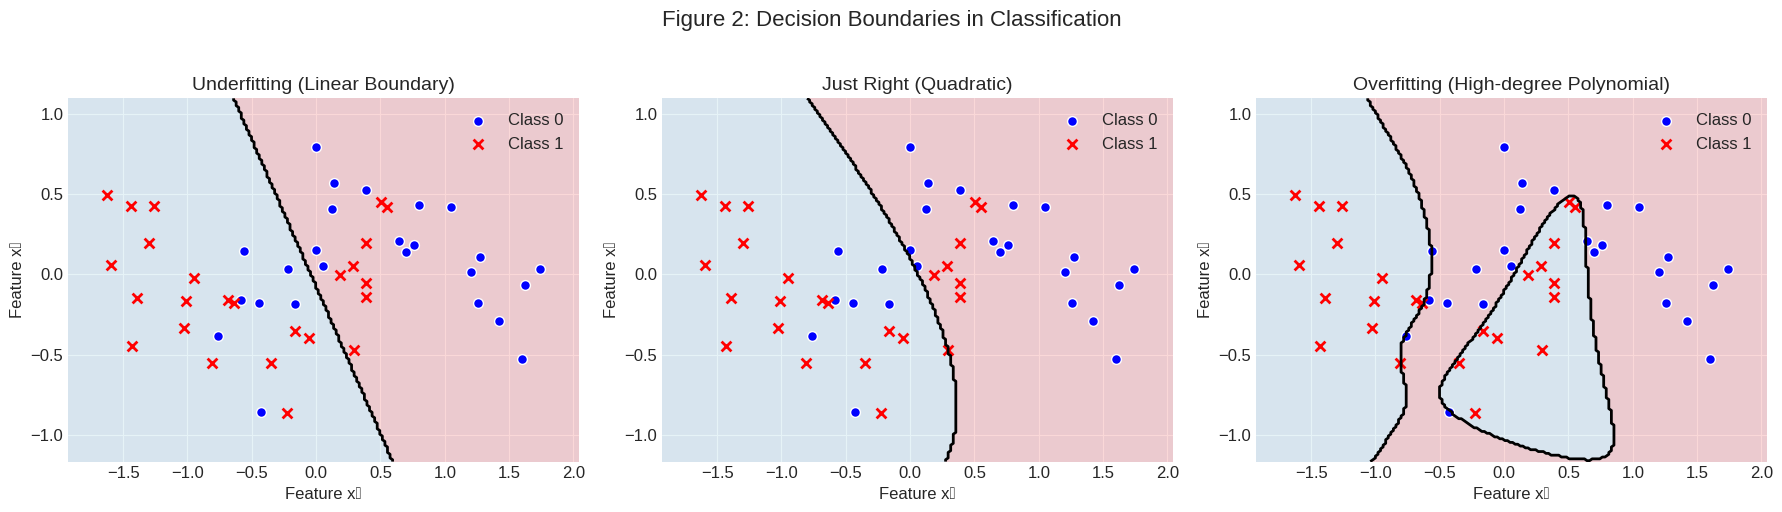

In [3]:
# Generate synthetic classification data
np.random.seed(42)
n_samples = 50

# Create two interleaving half circles
t = np.linspace(0, np.pi, n_samples//2)
X_class1 = np.column_stack([np.cos(t) + 0.5, np.sin(t) - 0.5]) + 0.2 * np.random.randn(n_samples//2, 2)
X_class2 = np.column_stack([np.cos(t + np.pi) - 0.5, np.sin(t + np.pi) + 0.5]) + 0.2 * np.random.randn(n_samples//2, 2)

X_class = np.vstack([X_class1, X_class2])
y_class = np.hstack([np.zeros(n_samples//2), np.ones(n_samples//2)])

# Function to plot decision boundary
def plot_decision_boundary(model, X, y, ax, title):
    # Create mesh
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predict on mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    ax.contourf(xx, yy, Z, alpha=0.3, levels=[-0.1, 0.5, 1.1], colors=['lightcoral', 'lightblue'])
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[y_class==0, 0], X[y_class==0, 1], color='blue', marker='o', s=50, label='Class 0', edgecolors='white')
    ax.scatter(X[y_class==1, 0], X[y_class==1, 1], color='red', marker='x', s=50, label='Class 1', linewidths=2)
    ax.set_xlabel('Feature x₁', fontsize=12)
    ax.set_ylabel('Feature x₂', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='upper right')
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])

# Create three models with increasing complexity
from sklearn.linear_model import LogisticRegression

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Underfit: simple linear logistic regression
model_under = LogisticRegression(C=1000, penalty='l2', solver='lbfgs')  # Large C = low regularization
model_under.fit(X_class, y_class)
plot_decision_boundary(model_under, X_class, y_class, axes[0], 'Underfitting (Linear Boundary)')

# Just right: polynomial features with moderate regularization
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_class)
model_just = LogisticRegression(C=10, penalty='l2', solver='lbfgs')
model_just.fit(X_poly, y_class)

# For visualization, we need to create a custom predictor
def predict_just(x):
    x_poly = poly.transform(x)
    return model_just.predict(x_poly)

# Create a wrapper class for the just-right model
class PolyLogistic:
    def __init__(self, poly, model):
        self.poly = poly
        self.model = model
    def predict(self, x):
        x_poly = self.poly.transform(x)
        return self.model.predict(x_poly)

model_just_wrapped = PolyLogistic(poly, model_just)
plot_decision_boundary(model_just_wrapped, X_class, y_class, axes[1], 'Just Right (Quadratic)')

# Overfit: high-degree polynomial with no regularization
poly_high = PolynomialFeatures(degree=15)
X_poly_high = poly_high.fit_transform(X_class)
model_over = LogisticRegression(C=1e6, penalty='l2', solver='lbfgs')  # Very large C = minimal regularization
model_over.fit(X_poly_high, y_class)

class PolyLogisticHigh:
    def __init__(self, poly, model):
        self.poly = poly
        self.model = model
    def predict(self, x):
        x_poly = self.poly.transform(x)
        return self.model.predict(x_poly)

model_over_wrapped = PolyLogisticHigh(poly_high, model_over)
plot_decision_boundary(model_over_wrapped, X_class, y_class, axes[2], 'Overfitting (High-degree Polynomial)')

plt.suptitle('Figure 2: Decision Boundaries in Classification', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Explanation**: This figure shows how decision boundaries change with model complexity in classification. The underfit model uses a simple linear boundary that misclassifies several points. The "just right" model with quadratic features creates a curved boundary that separates the classes well. The overfit model creates an overly complex boundary that contorts to perfectly classify every training point but would generalize poorly.

### 5.3 The Effect of Regularization Parameter λ

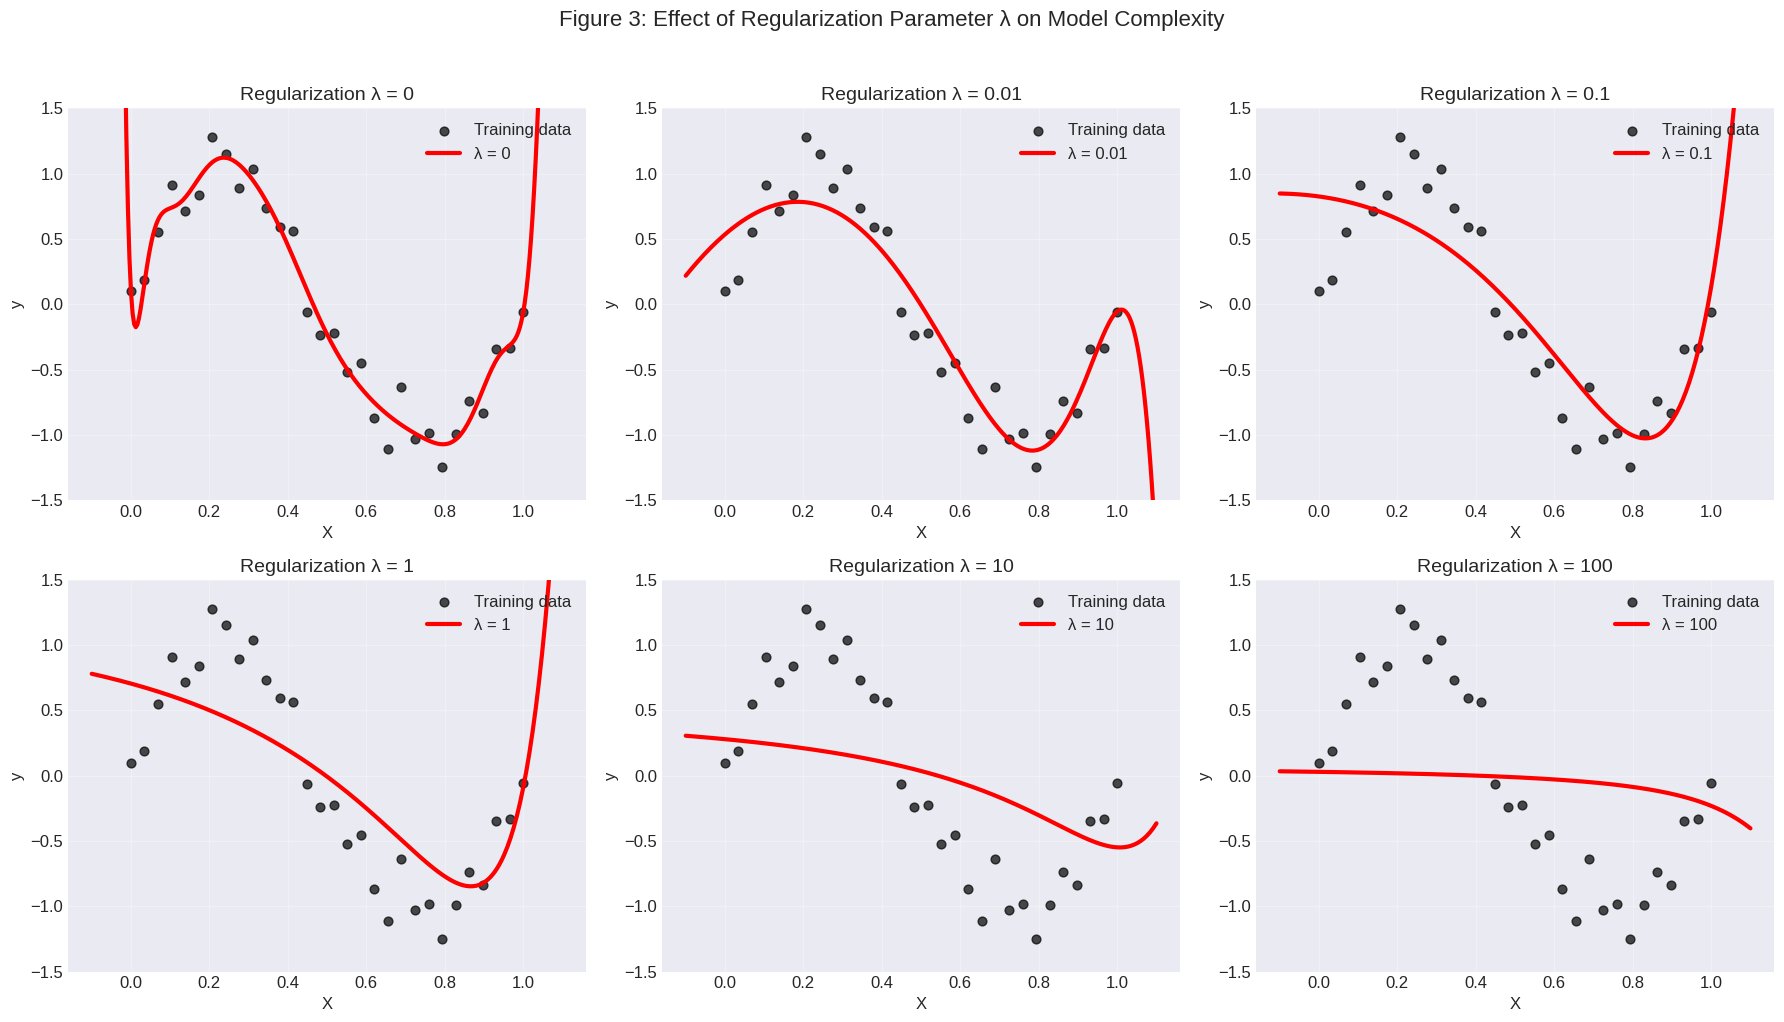

In [4]:
# Generate polynomial data with noise
np.random.seed(42)
X = np.linspace(0, 1, 30).reshape(-1, 1)
y = np.sin(2 * np.pi * X.ravel()) + 0.2 * np.random.randn(30)

# Test different regularization strengths
lambdas = [0, 0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, lambda_val in enumerate(lambdas):
    row, col = idx // 3, idx % 3

    # Create polynomial regression with Ridge (L2 regularization)
    model = make_pipeline(PolynomialFeatures(15), Ridge(alpha=lambda_val))
    model.fit(X, y)

    # Predict
    X_test = np.linspace(-0.1, 1.1, 300).reshape(-1, 1)
    y_pred = model.predict(X_test)

    # Plot
    axes[row, col].scatter(X, y, alpha=0.7, label='Training data', color='black', s=40)
    axes[row, col].plot(X_test, y_pred, color='red', linewidth=3, label=f'λ = {lambda_val}')
    axes[row, col].set_xlabel('X', fontsize=12)
    axes[row, col].set_ylabel('y', fontsize=12)
    axes[row, col].set_title(f'Regularization λ = {lambda_val}', fontsize=14)
    axes[row, col].legend(loc='upper right')
    axes[row, col].grid(True, alpha=0.3)
    axes[row, col].set_ylim([-1.5, 1.5])

plt.suptitle('Figure 3: Effect of Regularization Parameter λ on Model Complexity', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Explanation**: This visualization demonstrates how the regularization parameter λ controls model complexity. With λ = 0 (no regularization), the 15-degree polynomial wildly overfits the data. As λ increases, the model becomes smoother and less complex. At λ = 100, the model is nearly flat (underfitting). The optimal λ (around 0.01-0.1 in this case) balances fitting the data while maintaining reasonable smoothness.

### 5.4 Regularization Path: How Coefficients Shrink

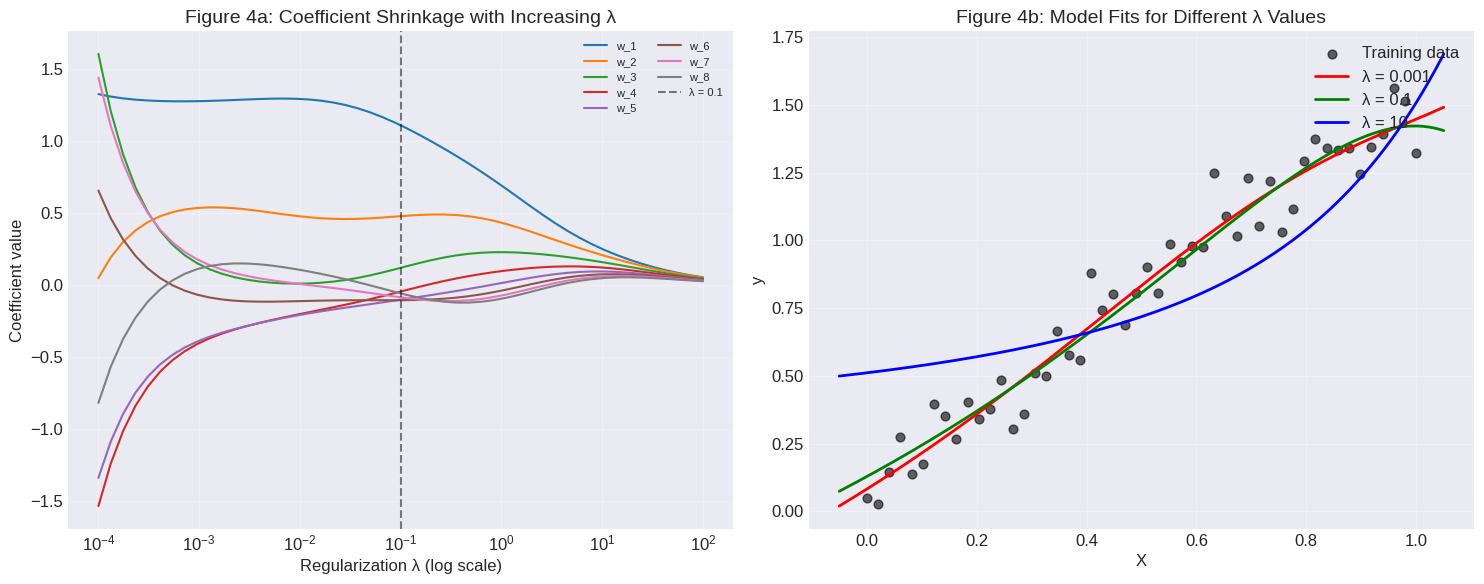

In [6]:
# Demonstrate coefficient shrinkage with increasing regularization
from sklearn.linear_model import Ridge

# Generate data
np.random.seed(42)
X = np.linspace(0, 1, 50).reshape(-1, 1)
y = 2 * X.ravel() - 0.5 * X.ravel()**2 + 0.1 * np.random.randn(50)

# Create polynomial features
poly = PolynomialFeatures(degree=8)
X_poly = poly.fit_transform(X)

# Test many lambda values
lambda_range = np.logspace(-4, 2, 50)
coefficients = []

for lambda_val in lambda_range:
    ridge = Ridge(alpha=lambda_val)
    ridge.fit(X_poly, y)
    coefficients.append(ridge.coef_)

coefficients = np.array(coefficients)

# Plot coefficient paths
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Coefficient paths
for i in range(1, coefficients.shape[1]):  # Skip intercept (index 0)
    axes[0].plot(lambda_range, coefficients[:, i], label=f'w_{i}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Regularization λ (log scale)', fontsize=12)
axes[0].set_ylabel('Coefficient value', fontsize=12)
axes[0].set_title('Figure 4a: Coefficient Shrinkage with Increasing λ', fontsize=14)
axes[0].axvline(x=0.1, color='black', linestyle='--', alpha=0.5, label='λ = 0.1')
axes[0].legend(loc='upper right', ncol=2, fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: Model fits for selected lambdas
selected_lambdas = [0.001, 0.1, 10]
colors = ['red', 'green', 'blue']

axes[1].scatter(X, y, alpha=0.6, label='Training data', color='black', s=40)
X_test = np.linspace(-0.05, 1.05, 200).reshape(-1, 1)
X_test_poly = poly.transform(X_test)

for lambda_val, color in zip(selected_lambdas, colors):
    ridge = Ridge(alpha=lambda_val)
    ridge.fit(X_poly, y)
    y_pred = ridge.predict(X_test_poly)
    axes[1].plot(X_test, y_pred, color=color, linewidth=2, label=f'λ = {lambda_val}')

axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Figure 4b: Model Fits for Different λ Values', fontsize=14)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Explanation**: The left plot shows how individual coefficients shrink toward zero as regularization strength increases. Higher-degree polynomial terms (which contribute to overfitting) shrink most rapidly. The right plot shows the resulting model fits for three selected λ values, illustrating the transition from overfitting (λ = 0.001) through balanced (λ = 0.1) to underfitting (λ = 10).

### 5.5 Training vs. Test Error: Finding the Optimal λ

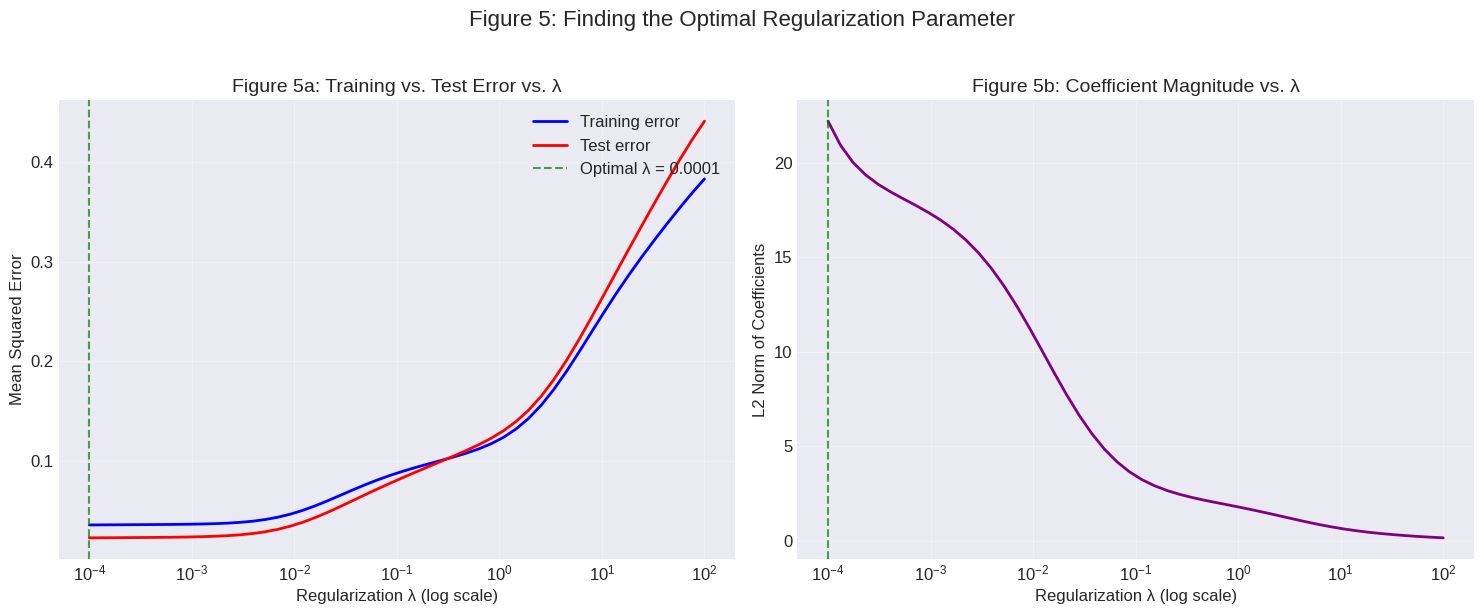

Optimal regularization parameter λ = 0.000100
Training error at optimal λ: 0.035519
Test error at optimal λ: 0.022582


In [7]:
# Generate data and split into train/test
np.random.seed(42)
X = np.linspace(0, 1, 100).reshape(-1, 1)
y = np.sin(2 * np.pi * X.ravel()) + 0.2 * np.random.randn(100)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create polynomial features
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Test many lambda values
lambda_range = np.logspace(-4, 2, 50)
train_errors = []
test_errors = []
coefficient_norms = []

for lambda_val in lambda_range:
    ridge = Ridge(alpha=lambda_val)
    ridge.fit(X_train_poly, y_train)

    # Calculate MSE
    train_pred = ridge.predict(X_train_poly)
    test_pred = ridge.predict(X_test_poly)

    train_mse = np.mean((train_pred - y_train)**2)
    test_mse = np.mean((test_pred - y_test)**2)

    train_errors.append(train_mse)
    test_errors.append(test_mse)
    coefficient_norms.append(np.linalg.norm(ridge.coef_))

# Find optimal lambda (minimum test error)
optimal_idx = np.argmin(test_errors)
optimal_lambda = lambda_range[optimal_idx]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Training vs Test Error
axes[0].plot(lambda_range, train_errors, 'b-', linewidth=2, label='Training error')
axes[0].plot(lambda_range, test_errors, 'r-', linewidth=2, label='Test error')
axes[0].axvline(x=optimal_lambda, color='green', linestyle='--', alpha=0.7,
                label=f'Optimal λ = {optimal_lambda:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Regularization λ (log scale)', fontsize=12)
axes[0].set_ylabel('Mean Squared Error', fontsize=12)
axes[0].set_title('Figure 5a: Training vs. Test Error vs. λ', fontsize=14)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 2: Coefficient Norm vs λ
axes[1].plot(lambda_range, coefficient_norms, 'purple', linewidth=2)
axes[1].axvline(x=optimal_lambda, color='green', linestyle='--', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_xlabel('Regularization λ (log scale)', fontsize=12)
axes[1].set_ylabel('L2 Norm of Coefficients', fontsize=12)
axes[1].set_title('Figure 5b: Coefficient Magnitude vs. λ', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 5: Finding the Optimal Regularization Parameter', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"Optimal regularization parameter λ = {optimal_lambda:.6f}")
print(f"Training error at optimal λ: {train_errors[optimal_idx]:.6f}")
print(f"Test error at optimal λ: {test_errors[optimal_idx]:.6f}")

**Explanation**: This crucial visualization shows how to select the optimal regularization parameter. The left plot reveals the classic bias-variance tradeoff: as λ increases, training error monotonically increases (worse fit to training data), but test error first decreases (reducing overfitting) then increases (entering underfitting regime). The optimal λ minimizes test error. The right plot shows how coefficient magnitudes shrink with increasing regularization, confirming that regularization works by penalizing large parameters.

## 6. Code Examples

### 6.1 Implementing Regularized Linear Regression from Scratch

Iteration 0: Loss = 6.028396
Iteration 200: Loss = 0.319341
Iteration 400: Loss = 0.131920
Iteration 600: Loss = 0.068388
Iteration 800: Loss = 0.046385
Iteration 0: Loss = 6.028407
Iteration 200: Loss = 0.319497
Iteration 400: Loss = 0.132032
Iteration 600: Loss = 0.068503
Iteration 800: Loss = 0.046506
Iteration 0: Loss = 6.028508
Iteration 200: Loss = 0.320895
Iteration 400: Loss = 0.133038
Iteration 600: Loss = 0.069527
Iteration 800: Loss = 0.047580
Iteration 0: Loss = 6.029520
Iteration 200: Loss = 0.334476
Iteration 400: Loss = 0.142392
Iteration 600: Loss = 0.078626
Iteration 800: Loss = 0.056721
Iteration 0: Loss = 6.039639
Iteration 200: Loss = 0.437012
Iteration 400: Loss = 0.189171
Iteration 600: Loss = 0.109606
Iteration 800: Loss = 0.080420


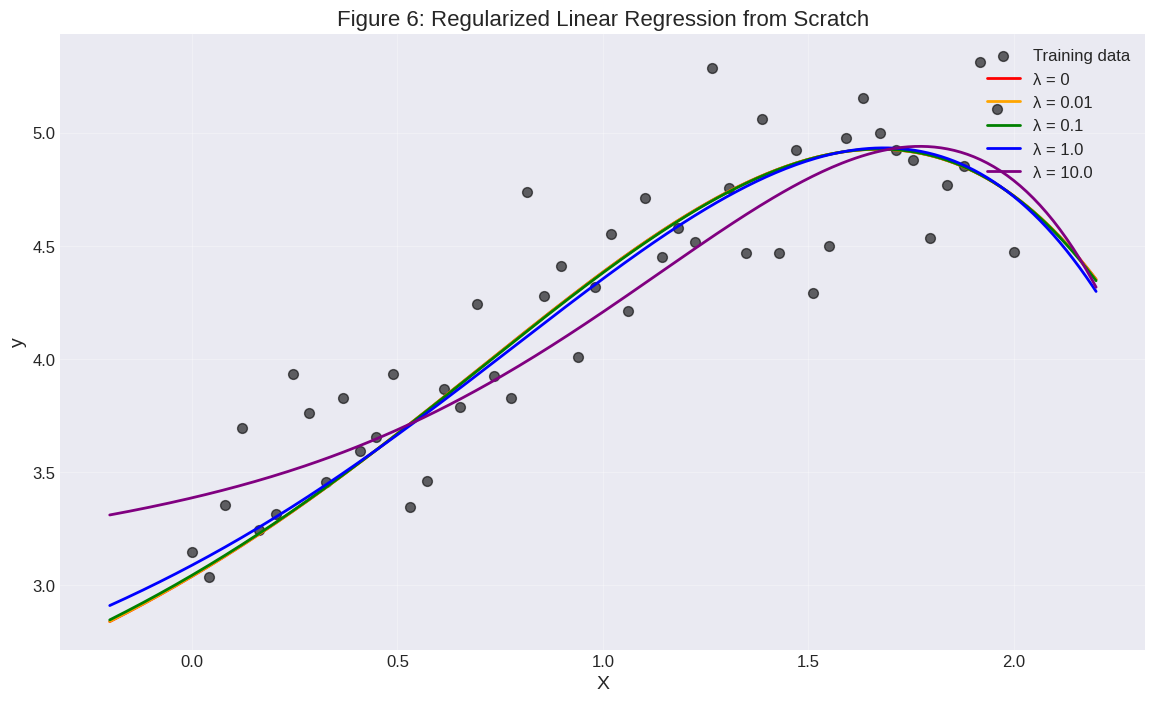

Iteration 0: Loss = 6.028396
Iteration 200: Loss = 0.319341
Iteration 400: Loss = 0.131920
Iteration 0: Loss = 6.028407
Iteration 200: Loss = 0.319497
Iteration 400: Loss = 0.132032
Iteration 0: Loss = 6.028508
Iteration 200: Loss = 0.320895
Iteration 400: Loss = 0.133038


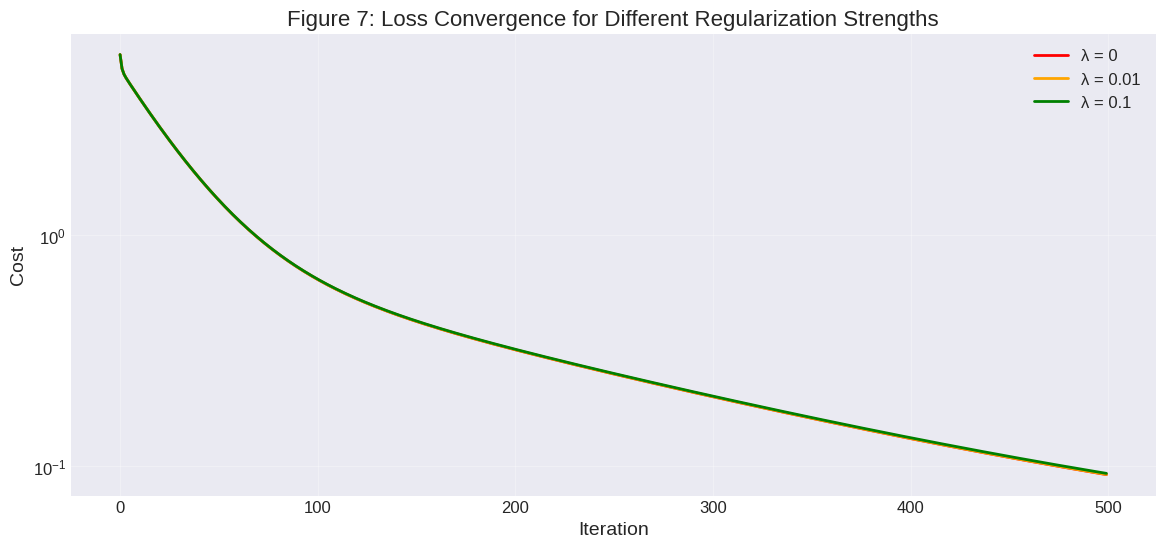

In [8]:
import numpy as np
import matplotlib.pyplot as plt

class RegularizedLinearRegression:
    """
    Linear Regression with L2 Regularization (Ridge Regression)
    Implemented from scratch using gradient descent
    """

    def __init__(self, lambda_reg=0.1, learning_rate=0.01, n_iterations=1000):
        self.lambda_reg = lambda_reg  # Regularization parameter
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        """
        Fit the model using gradient descent with regularization

        Args:
            X: numpy array of shape (m, n) - training examples
            y: numpy array of shape (m,) - target values
        """
        m, n = X.shape

        # Initialize parameters
        self.w = np.zeros(n)
        self.b = 0

        # Gradient descent
        for iteration in range(self.n_iterations):
            # Forward pass: make predictions
            y_pred = self.predict(X)

            # Calculate gradients
            # For w: (1/m) * X.T @ (y_pred - y) + (lambda/m) * w
            dw = (1/m) * X.T @ (y_pred - y) + (self.lambda_reg/m) * self.w
            # For b: (1/m) * sum(y_pred - y)  (no regularization for bias)
            db = (1/m) * np.sum(y_pred - y)

            # Update parameters
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # Calculate and store loss
            loss = self._compute_cost(X, y)
            self.loss_history.append(loss)

            # Optional: print progress
            if iteration % 200 == 0:
                print(f"Iteration {iteration}: Loss = {loss:.6f}")

        return self

    def predict(self, X):
        """Make predictions for input X"""
        return X @ self.w + self.b

    def _compute_cost(self, X, y):
        """
        Compute regularized cost function:
        J(w,b) = (1/2m) * sum((y_pred - y)^2) + (lambda/2m) * sum(w^2)
        """
        m = len(y)
        y_pred = self.predict(X)
        mse = (1/(2*m)) * np.sum((y_pred - y)**2)
        regularization = (self.lambda_reg/(2*m)) * np.sum(self.w**2)
        return mse + regularization

# Generate synthetic data with polynomial features
np.random.seed(42)
m = 50
X = np.linspace(0, 2, m).reshape(-1, 1)
# True relationship: quadratic with some noise
y_true = 3 + 2 * X.ravel() - 0.5 * X.ravel()**2
y = y_true + 0.3 * np.random.randn(m)

# Create polynomial features manually
X_poly = np.column_stack([X, X**2, X**3, X**4, X**5])

# Test different regularization strengths
lambdas = [0, 0.01, 0.1, 1.0, 10.0]
colors = ['red', 'orange', 'green', 'blue', 'purple']

plt.figure(figsize=(14, 8))

# Plot training data
plt.scatter(X, y, alpha=0.6, label='Training data', color='black', s=50)

# Test points for smooth curve
X_test = np.linspace(-0.2, 2.2, 300).reshape(-1, 1)
X_test_poly = np.column_stack([X_test, X_test**2, X_test**3, X_test**4, X_test**5])

# Train models and plot predictions
for lambda_val, color in zip(lambdas, colors):
    model = RegularizedLinearRegression(lambda_reg=lambda_val,
                                        learning_rate=0.01,
                                        n_iterations=1000)
    model.fit(X_poly, y)
    y_pred_test = model.predict(X_test_poly)

    plt.plot(X_test, y_pred_test, color=color, linewidth=2,
             label=f'λ = {lambda_val}')

plt.xlabel('X', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.title('Figure 6: Regularized Linear Regression from Scratch', fontsize=16)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Plot loss convergence for different lambdas
plt.figure(figsize=(14, 6))

for lambda_val, color in zip(lambdas[:3], colors[:3]):  # Plot first 3 for clarity
    model = RegularizedLinearRegression(lambda_reg=lambda_val,
                                        learning_rate=0.01,
                                        n_iterations=500)
    model.fit(X_poly, y)
    plt.plot(model.loss_history, color=color, linewidth=2,
             label=f'λ = {lambda_val}')

plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Cost', fontsize=14)
plt.title('Figure 7: Loss Convergence for Different Regularization Strengths', fontsize=16)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

### 6.2 Regularized Logistic Regression Implementation

/tmp/ipykernel_575/2456300581.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_575/2456300581.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


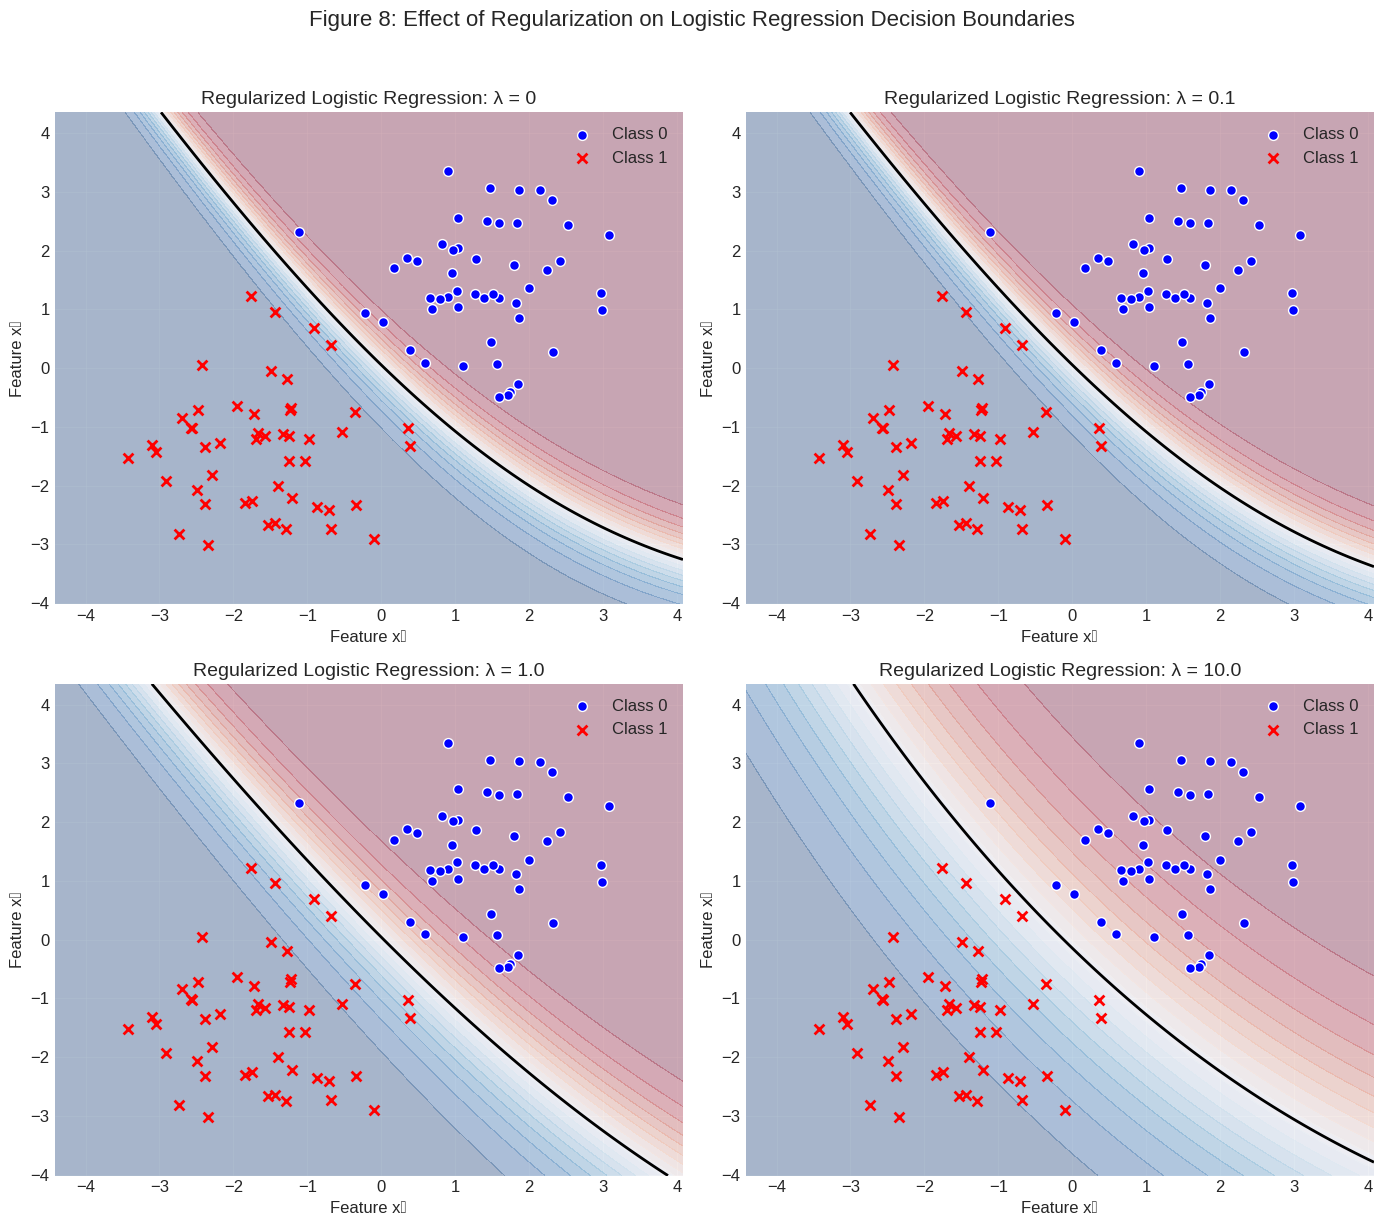

In [9]:

import numpy as np
import matplotlib.pyplot as plt

class RegularizedLogisticRegression:
    """
    Logistic Regression with L2 Regularization
    Implemented from scratch using gradient descent
    """

    def __init__(self, lambda_reg=0.1, learning_rate=0.01, n_iterations=1000):
        self.lambda_reg = lambda_reg
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        self.loss_history = []

    def _sigmoid(self, z):
        """Sigmoid activation function"""
        # Clip to avoid overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        """
        Fit the model using gradient descent with regularization

        Args:
            X: numpy array of shape (m, n) - training examples
            y: numpy array of shape (m,) - binary labels (0 or 1)
        """
        m, n = X.shape

        # Initialize parameters
        self.w = np.zeros(n)
        self.b = 0

        # Gradient descent
        for iteration in range(self.n_iterations):
            # Forward pass
            z = X @ self.w + self.b
            y_pred = self._sigmoid(z)

            # Calculate gradients
            # For w: (1/m) * X.T @ (y_pred - y) + (lambda/m) * w
            dw = (1/m) * X.T @ (y_pred - y) + (self.lambda_reg/m) * self.w
            # For b: (1/m) * sum(y_pred - y)
            db = (1/m) * np.sum(y_pred - y)

            # Update parameters
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # Calculate and store loss
            loss = self._compute_cost(X, y)
            self.loss_history.append(loss)

        return self

    def predict_proba(self, X):
        """Predict probability of class 1"""
        z = X @ self.w + self.b
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        """Predict class labels (0 or 1)"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

    def _compute_cost(self, X, y):
        """
        Compute regularized cross-entropy cost:
        J(w,b) = -(1/m) * sum(y*log(y_pred) + (1-y)*log(1-y_pred))
                 + (lambda/2m) * sum(w^2)
        """
        m = len(y)
        y_pred = self.predict_proba(X)

        # Avoid log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        # Cross-entropy loss
        cross_entropy = -(1/m) * np.sum(
            y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred)
        )

        # Regularization term (excluding bias)
        regularization = (self.lambda_reg / (2 * m)) * np.sum(self.w**2)

        return cross_entropy + regularization

# Generate synthetic classification data
np.random.seed(42)
m = 100

# Create two classes with some overlap
X_class1 = np.random.randn(m//2, 2) + np.array([1.5, 1.5])
X_class2 = np.random.randn(m//2, 2) + np.array([-1.5, -1.5])
X = np.vstack([X_class1, X_class2])
y = np.hstack([np.zeros(m//2), np.ones(m//2)])

# Add polynomial features to create a non-linear problem
X_poly = np.column_stack([X, X[:, 0]**2, X[:, 1]**2, X[:, 0]*X[:, 1]])

# Test different regularization strengths
lambdas = [0, 0.1, 1.0, 10.0]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, lambda_val in enumerate(lambdas):
    row, col = idx // 2, idx % 2

    # Train model
    model = RegularizedLogisticRegression(lambda_reg=lambda_val,
                                          learning_rate=0.1,
                                          n_iterations=2000)
    model.fit(X_poly, y)

    # Create mesh for decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Create polynomial features for mesh points
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_poly = np.column_stack([mesh_points,
                                  mesh_points[:, 0]**2,
                                  mesh_points[:, 1]**2,
                                  mesh_points[:, 0] * mesh_points[:, 1]])

    # Predict on mesh
    Z = model.predict_proba(mesh_poly)
    Z = Z.reshape(xx.shape)

    # Plot
    axes[row, col].contourf(xx, yy, Z, alpha=0.3, levels=np.linspace(0, 1, 20), cmap='RdBu')
    axes[row, col].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    axes[row, col].scatter(X[y==0, 0], X[y==0, 1], color='blue', marker='o', s=50,
                          label='Class 0', edgecolors='white')
    axes[row, col].scatter(X[y==1, 0], X[y==1, 1], color='red', marker='x', s=50,
                          label='Class 1', linewidths=2)
    axes[row, col].set_xlabel('Feature x₁', fontsize=12)
    axes[row, col].set_ylabel('Feature x₂', fontsize=12)
    axes[row, col].set_title(f'Regularized Logistic Regression: λ = {lambda_val}', fontsize=14)
    axes[row, col].legend(loc='upper right')
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle('Figure 8: Effect of Regularization on Logistic Regression Decision Boundaries',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



## 7. Key Takeaways

1. **Overfitting vs. Underfitting**: Overfitting (high variance) occurs when a model learns noise in the training data, while underfitting (high bias) occurs when a model is too simple to capture underlying patterns.

2. **The Bias-Variance Tradeoff**: Finding the optimal model complexity requires balancing bias (error from wrong assumptions) and variance (error from sensitivity to training data fluctuations).

3. **Regularization is a Smooth Alternative to Feature Selection**: Instead of eliminating features entirely, regularization gently reduces their impact by penalizing large parameter values.

4. **The Regularization Parameter λ Controls Complexity**: Small λ values lead to overfitting; large λ values lead to underfitting. The optimal λ minimizes test error.

5. **Regularization Works by Shrinking Parameters**: In gradient descent, regularization multiplies parameters by a factor slightly less than 1 on each iteration, gradually shrinking them.

6. **Bias Term is Usually Not Regularized**: By convention, we regularize only the feature weights (wⱼ) and not the bias term (b), though including b makes little practical difference.

7. **Regularization Applies to Both Regression and Classification**: The same principle—adding a penalty term to the cost function—works for both linear regression and logistic regression.

8. **Model Selection Requires Validation**: The optimal λ should be chosen based on performance on a validation set or cross-validation, not on training error alone.

## 8. Quick Revision

### Key Formulas

| **Concept** | **Formula** | **Explanation** |
|-------------|-------------|------------------|
| **Linear Regression Cost** | $J(\vec{w},b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})^2$ | Mean squared error |
| **Regularized Linear Regression Cost** | $J(\vec{w},b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2$ | MSE + penalty for large wⱼ |
| **Regularized Logistic Regression Cost** | $J(\vec{w},b) = -\frac{1}{m}\sum_{i=1}^{m}[y^{(i)}\log(f_{\vec{w},b}(\vec{x}^{(i)})) + (1-y^{(i)})\log(1-f_{\vec{w},b}(\vec{x}^{(i)}))] + \frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2$ | Cross-entropy + penalty |
| **Regularized Gradient Descent (wⱼ)** | $w_j := w_j - \alpha\left[\frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})x_j^{(i)} + \frac{\lambda}{m}w_j\right]$ | Update with shrinkage |
| **Gradient Descent (b)** | $b := b - \alpha\frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})$ | No regularization on bias |

### Definitions at a Glance

- **Overfitting (High Variance)**: Model fits training data perfectly but fails on new data
- **Underfitting (High Bias)**: Model fails to fit even training data
- **Regularization**: Technique to reduce overfitting by penalizing large parameters
- **λ (Lambda)**: Regularization parameter controlling strength of penalty
- **Generalization**: Model's ability to perform well on unseen data

### Three Ways to Address Overfitting

1. **Collect more training data** (most effective when possible)
2. **Select fewer features** (feature selection)
3. **Apply regularization** (reduce parameter magnitudes)

### Regularization Intuition
- With regularization, each gradient descent step: $w_j := w_j(1 - \alpha\frac{\lambda}{m}) - \text{(usual update)}$
- The term $(1 - \alpha\frac{\lambda}{m})$ is slightly less than 1, shrinking wⱼ each iteration

---

*"When I walk around Silicon Valley, there are many engineers using machine learning to create a ton of value... knowing things like when and how to reduce overfitting turns out to be one of the very valuable skills in the real world as well."* — Andrew Ng